# TP : Apprentissage Non Supervisé (exercice)
## Dataset : Wine recognition (cultivars de vins, scikit-learn)

> **Note dataset :** le TP original prévoyait Wine Quality (vins rouges portugais) via
> `fetch_openml`, mais l'accès réseau à OpenML n'est pas disponible dans cet environnement
> d'exécution. On utilise donc le dataset **Wine recognition** (178 vins, 13 variables
> physico-chimiques), intégré directement à scikit-learn (`load_wine`, aucun téléchargement
> requis) — c'est d'ailleurs le dataset du TP original du cours avant l'adaptation
> "Wine Quality" mentionnée ci-dessous. La méthode (K-Means, DBSCAN, Isolation Forest, CAH,
> qualification, validation) est strictement identique. Bonus : ce dataset a un vrai label de
> cultivar (3 classes), ce qui permet une validation plus directe qu'un palier de qualité construit
> a posteriori.

**Objectifs :**
- Appliquer K-Means, DBSCAN, Isolation Forest et CAH sur des données réelles
- Optimiser les hyperparamètres (k, eps/min_samples, contamination)
- Qualifier et valider les clusters obtenus

**Datamap (dictionnaire des données) :** 13 mesures physico-chimiques par échantillon de vin.

| Colonne | Description |
|---|---|
| alcohol | Teneur en alcool (%) |
| malic_acid | Acide malique |
| ash | Cendres (résidu minéral) |
| alcalinity_of_ash | Alcalinité des cendres |
| magnesium | Teneur en magnésium |
| total_phenols | Phénols totaux |
| flavanoids | Flavonoïdes |
| nonflavanoid_phenols | Phénols non flavonoïdes |
| proanthocyanins | Proanthocyanidines |
| color_intensity | Intensité de la couleur |
| hue | Teinte |
| od280/od315_of_diluted_wines | Ratio d'absorbance OD280/OD315 (pureté des protéines) |
| proline | Teneur en proline (acide aminé) |

**Note :** le cultivar (`target`, 3 classes : 0, 1, 2) est mis de côté et n'est utilisé qu'à la
toute fin, pour valider les clusters obtenus.

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/01_non_supervise/tp_non_supervise.ipynb` (même méthode).

---
## 0. Installation & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement des données

In [2]:
# Wine recognition : 178 echantillons, 13 mesures physico-chimiques + un cultivar (0, 1, 2)
# Chargement direct depuis scikit-learn (dataset embarque, aucune authentification/reseau requis)
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df_raw = wine.frame.drop(columns=['target']).astype(float)
quality = wine.frame['target'].astype(int)  # cultivar, garde a part pour la validation (section 9)

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 178 lignes x 13 colonnes


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [3]:
df_raw.describe().round(2)

       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.13             0.41   
25%         

In [4]:
print(df_raw.isnull().sum().sum(), "valeurs manquantes")

0 valeurs manquantes


---
## 2. Prétraitement

Les algorithmes de clustering (surtout K-Means et DBSCAN) sont sensibles aux échelles.
On normalise toutes les features avec `StandardScaler` (moyenne=0, écart-type=1).

In [5]:
# TODO : standardiser les features (moyenne=0, ecart-type=1)
# Indice : StandardScaler().fit_transform(df_raw), puis remettre en DataFrame avec les memes colonnes
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_raw), columns=df_raw.columns)

print("Moyenne après scaling :", X_scaled.mean().round(6).max())
print("Std après scaling    :", X_scaled.std().round(2).min())


Moyenne après scaling : -0.0
Std après scaling    : 1.0


### Réduction dimensionnelle pour la visualisation (PCA 2D)
On réduit à 2 composantes uniquement pour visualiser : les modèles tournent sur les 11 features.

Variance expliquée : PC1=36.2%, PC2=19.2%
Total : 55.4%


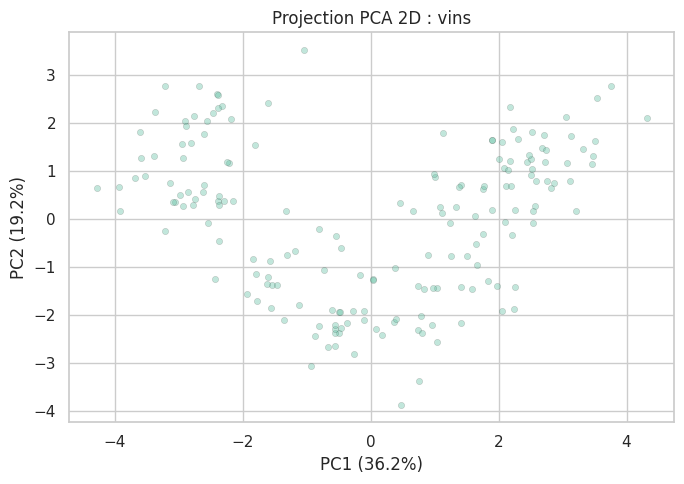

In [6]:
# TODO : reduire a 2 composantes avec PCA pour la visualisation
# Indice : PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total : {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, edgecolors='k', linewidths=0.2, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Projection PCA 2D : vins')
plt.tight_layout()
plt.show()


---
## 3. K-Means

### 3.1 Optimisation du nombre de clusters (k)
On teste k de 2 à 10 et on compare :
- **Inertie** (elbow method) : somme des distances au centroïde
- **Score de silhouette** : mesure de compacité et séparation

k optimal (silhouette max) : 3 → score = 0.2849


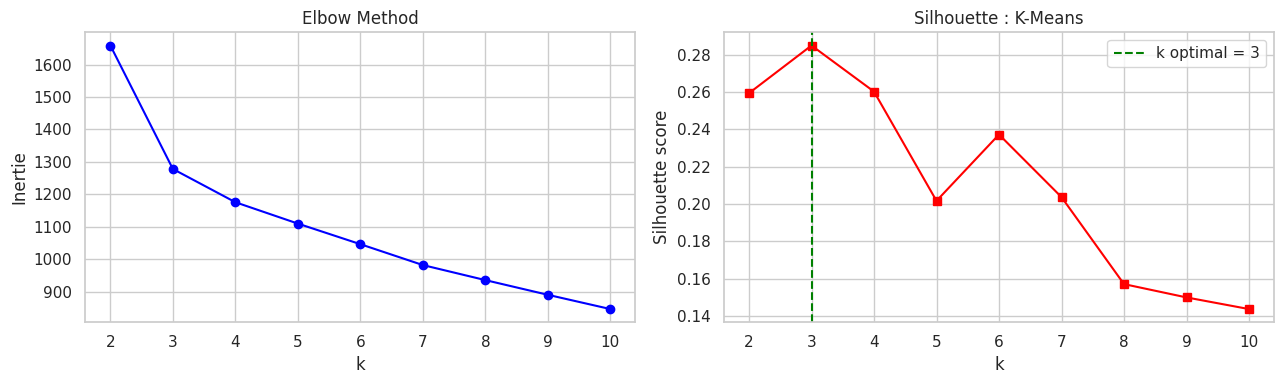

In [7]:
K_range = range(2, 11)
inertias = []
silhouettes_kmeans = []

for k in K_range:
    # TODO : entrainer un KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10), stocker l'inertie et le score de silhouette
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_kmeans.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes_kmeans, 'rs-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : K-Means')

best_k = list(K_range)[np.argmax(silhouettes_kmeans)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"k optimal (silhouette max) : {best_k} → score = {max(silhouettes_kmeans):.4f}")


### 3.2 Entraînement avec k optimal

In [8]:
# TODO : entrainer le KMeans final avec k=best_k et recuperer les labels
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = km_best.fit_predict(X_scaled)

print(f"Silhouette K-Means (k={best_k}) : {silhouette_score(X_scaled, labels_kmeans):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_kmeans).value_counts().sort_index())


Silhouette K-Means (k=3) : 0.2849
Distribution des clusters :
0    65
1    51
2    62
Name: count, dtype: int64


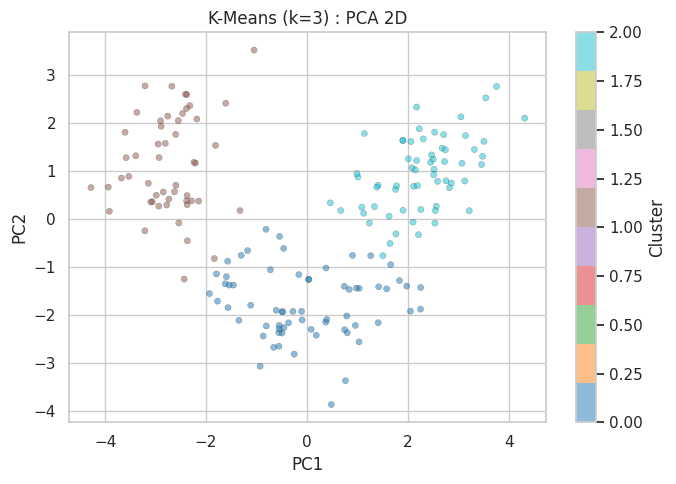

In [9]:
# Visualisation PCA
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={best_k}) : PCA 2D')
plt.tight_layout()
plt.show()


### 3.3 Silhouette plot par échantillon

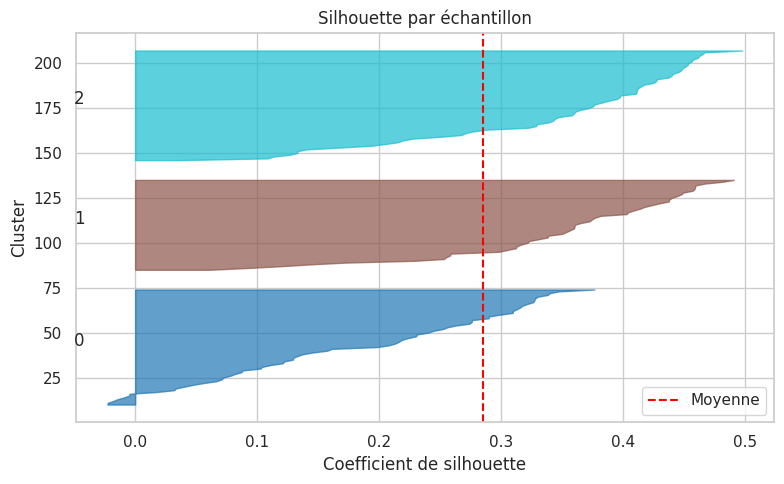

In [10]:
sample_silhouette_values = silhouette_samples(X_scaled, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    ith_values = sample_silhouette_values[labels_kmeans == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, labels_kmeans), color='red', linestyle='--', label='Moyenne')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette par échantillon')
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. DBSCAN

DBSCAN regroupe les points denses et marque les points isolés comme **bruit** (label = -1).
Deux hyperparamètres clés :
- `eps` : rayon de voisinage
- `min_samples` : nombre minimum de voisins pour former un cluster dense

In [11]:
from itertools import product

eps_values = np.arange(0.5, 3.0, 0.25)
min_samples_values = [3, 5, 7, 10]

results_dbscan = []

for eps, min_s in product(eps_values, min_samples_values):
    # TODO : entrainer un DBSCAN(eps=eps, min_samples=min_s) et recuperer les labels
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        sil = silhouette_score(X_scaled, labels)
        results_dbscan.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil})

df_dbscan_results = pd.DataFrame(results_dbscan).sort_values('silhouette', ascending=False)
print(f"{len(df_dbscan_results)} configurations valides (≥2 clusters)")
df_dbscan_results.head(10)


12 configurations valides (≥2 clusters)


     eps  min_samples  n_clusters  n_noise  silhouette
11  2.50           10           2       32    0.204389
7   2.25            3           2       37    0.198443
8   2.25            5           2       46    0.165469
9   2.25            7           2       57    0.133591
10  2.25           10           2       75    0.091084
4   2.00            3           5       64    0.031407
6   2.00            7           3      110   -0.027448
5   2.00            5           5       85   -0.032906
1   1.75            3          11       98   -0.124735
3   1.75            7           2      164   -0.158270

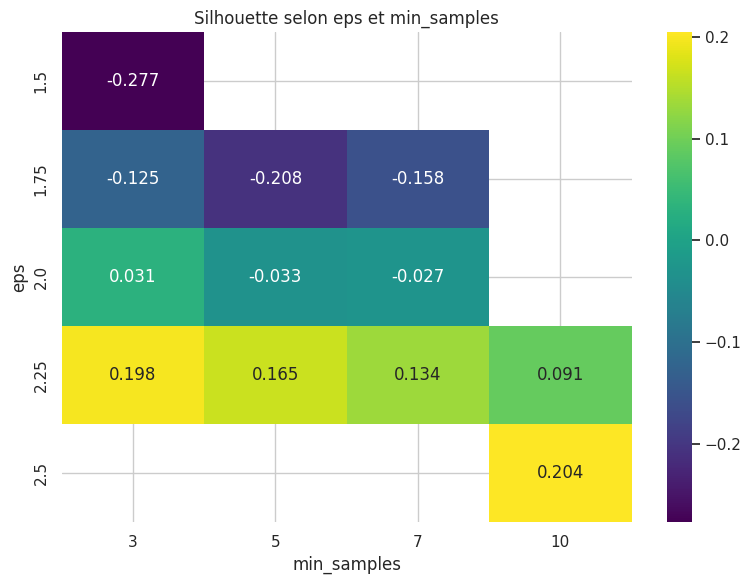

In [12]:
# Heatmap silhouette
pivot = df_dbscan_results.pivot_table(index='eps', columns='min_samples', values='silhouette', aggfunc='max')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Silhouette selon eps et min_samples')
plt.tight_layout()
plt.show()


### 4.2 Entraînement avec les meilleurs paramètres

In [13]:
best_dbscan = df_dbscan_results.iloc[0]
print(f"Meilleurs paramètres : eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}")
print(f"Clusters : {int(best_dbscan['n_clusters'])} | Bruit : {int(best_dbscan['n_noise'])} points | Silhouette : {best_dbscan['silhouette']:.4f}")

# TODO : entrainer le DBSCAN final avec les meilleurs parametres et recuperer les labels
db_best = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
labels_dbscan = db_best.fit_predict(X_scaled)


Meilleurs paramètres : eps=2.50, min_samples=10
Clusters : 2 | Bruit : 32 points | Silhouette : 0.2044


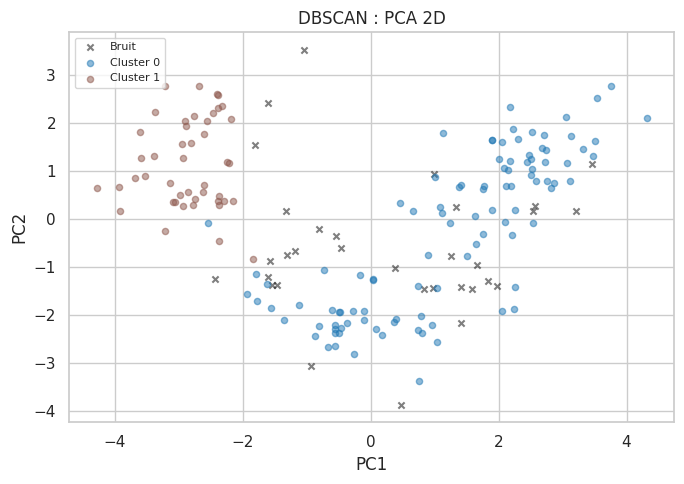

In [14]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels_dbscan == label
    color = 'black' if label == -1 else cmap(label / max(1, best_dbscan['n_clusters']))
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, alpha=0.5, s=20,
                label=f'Bruit' if label == -1 else f'Cluster {label}')

plt.legend(fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN : PCA 2D')
plt.tight_layout()
plt.show()


---
## 5. Isolation Forest

Isolation Forest est un algorithme de **détection d'anomalies** :
il isole les points atypiques (vins aux propriétés chimiques inhabituelles) en construisant des arbres de partitionnement aléatoire.

Contamination optimale : 0.02 → silhouette = 0.2618


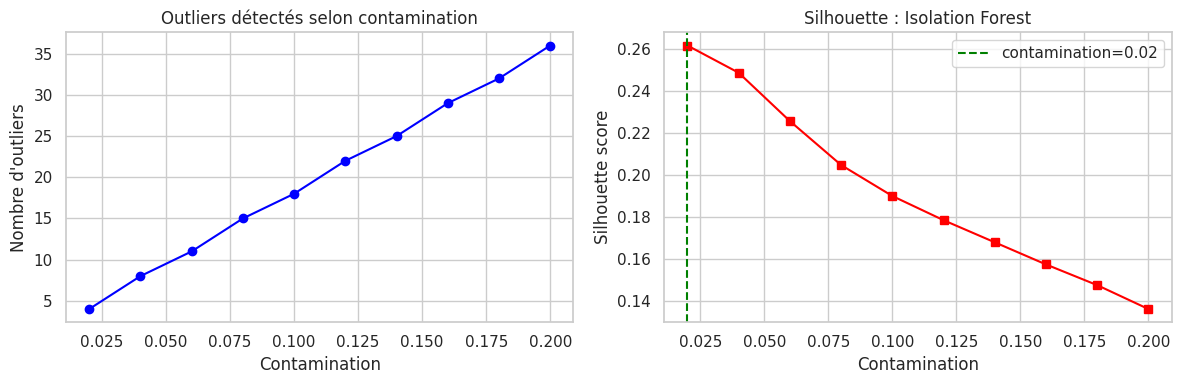

In [15]:
contamination_values = np.arange(0.02, 0.21, 0.02)
results_if = []

for cont in contamination_values:
    # TODO : entrainer un IsolationForest(contamination=cont, random_state=RANDOM_STATE) et recuperer les predictions (1=inlier, -1=outlier)
    iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE)
    preds = iso.fit_predict(X_scaled)
    n_outliers = (preds == -1).sum()

    if len(set(preds)) == 2:
        sil = silhouette_score(X_scaled, preds)
        results_if.append({'contamination': round(cont, 2), 'n_outliers': n_outliers, 'pct_outliers': round(cont * 100, 1), 'silhouette': sil})

df_if_results = pd.DataFrame(results_if)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_if_results['contamination'], df_if_results['n_outliers'], 'bo-')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel("Nombre d'outliers")
axes[0].set_title('Outliers détectés selon contamination')

axes[1].plot(df_if_results['contamination'], df_if_results['silhouette'], 'rs-')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : Isolation Forest')

best_cont = df_if_results.loc[df_if_results['silhouette'].idxmax(), 'contamination']
axes[1].axvline(best_cont, color='green', linestyle='--', label=f'contamination={best_cont}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Contamination optimale : {best_cont} → silhouette = {df_if_results['silhouette'].max():.4f}")


### 5.2 Détection d'anomalies avec contamination optimale

In [16]:
# TODO : entrainer l'Isolation Forest final avec contamination=best_cont
iso_best = IsolationForest(contamination=best_cont, random_state=RANDOM_STATE)
labels_if = iso_best.fit_predict(X_scaled)  # 1 = normal, -1 = anomalie
scores_if = iso_best.decision_function(X_scaled)  # score d'anomalie (plus bas = plus anormal)

n_outliers = (labels_if == -1).sum()
print(f"Outliers détectés : {n_outliers} ({n_outliers/len(labels_if):.1%} du dataset)")
print(f"Silhouette : {silhouette_score(X_scaled, labels_if):.4f}")


Outliers détectés : 4 (2.2% du dataset)
Silhouette : 0.2618


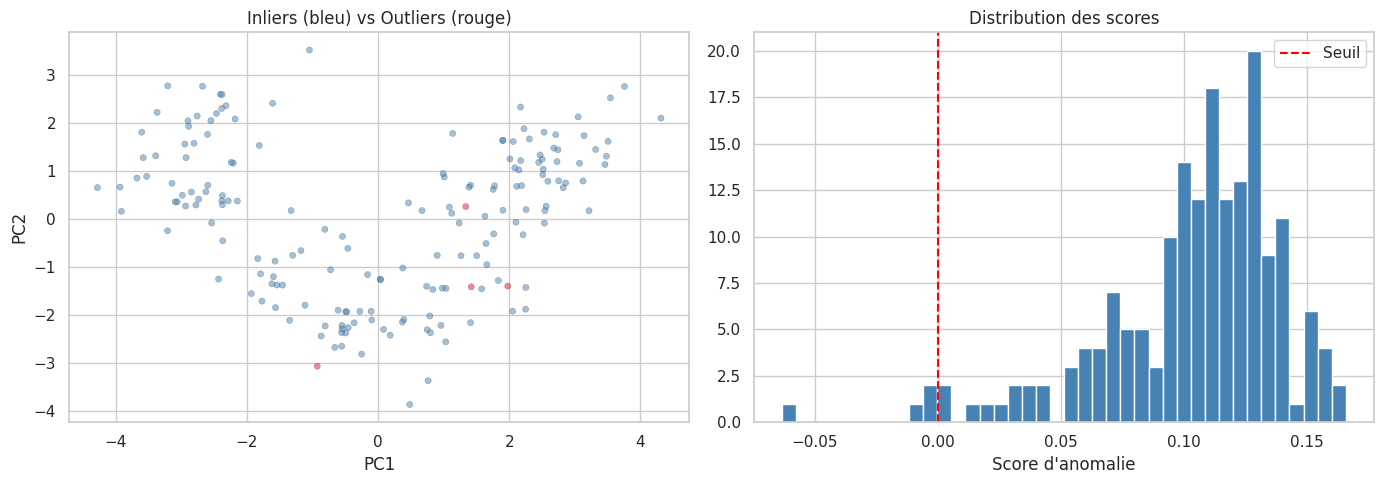

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_if = ['steelblue' if l == 1 else 'crimson' for l in labels_if]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_if, alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[0].set_title('Inliers (bleu) vs Outliers (rouge)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].hist(scores_if, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(np.percentile(scores_if, best_cont * 100), color='red', linestyle='--', label='Seuil')
axes[1].set_xlabel('Score d\'anomalie')
axes[1].set_title('Distribution des scores')
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.3 Isolation Forest + K-Means : clustering des inliers
On peut combiner les deux : filtrer les anomalies avec Isolation Forest, puis clustériser les inliers.

Silhouette K-Means sur inliers : 0.2942 (vs 0.2849 sur tout le dataset)


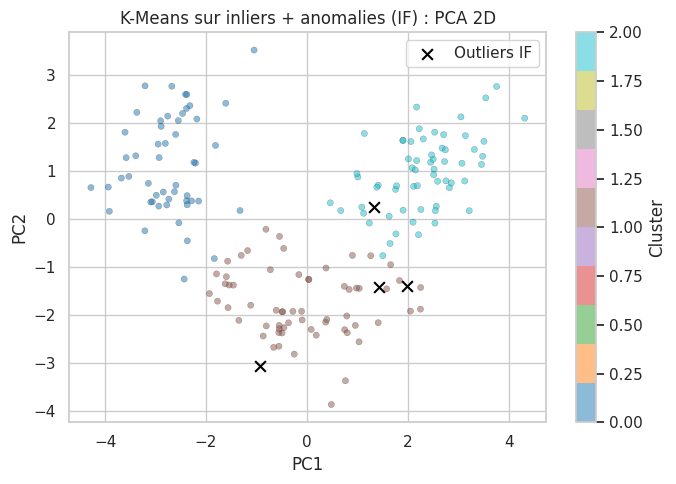

In [18]:
mask_inliers = labels_if == 1
X_inliers = X_scaled[mask_inliers]
X_pca_inliers = X_pca[mask_inliers]

# TODO : entrainer un KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10) sur les inliers uniquement
km_inliers = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_combined = km_inliers.fit_predict(X_inliers)

sil_combined = silhouette_score(X_inliers, labels_combined)
print(f"Silhouette K-Means sur inliers : {sil_combined:.4f} (vs {silhouette_score(X_scaled, labels_kmeans):.4f} sur tout le dataset)")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_inliers[:, 0], X_pca_inliers[:, 1], c=labels_combined, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.scatter(X_pca[~mask_inliers, 0], X_pca[~mask_inliers, 1], marker='x', color='black', s=60, label='Outliers IF', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sur inliers + anomalies (IF) : PCA 2D')
plt.tight_layout()
plt.show()


---
## 6. CAH : Clustering Agglomératif Hiérarchique

La CAH construit un arbre (dendrogramme) en fusionnant itérativement les points les plus proches.
Avantages : pas besoin de spécifier k à l'avance, on peut couper l'arbre à différents niveaux.

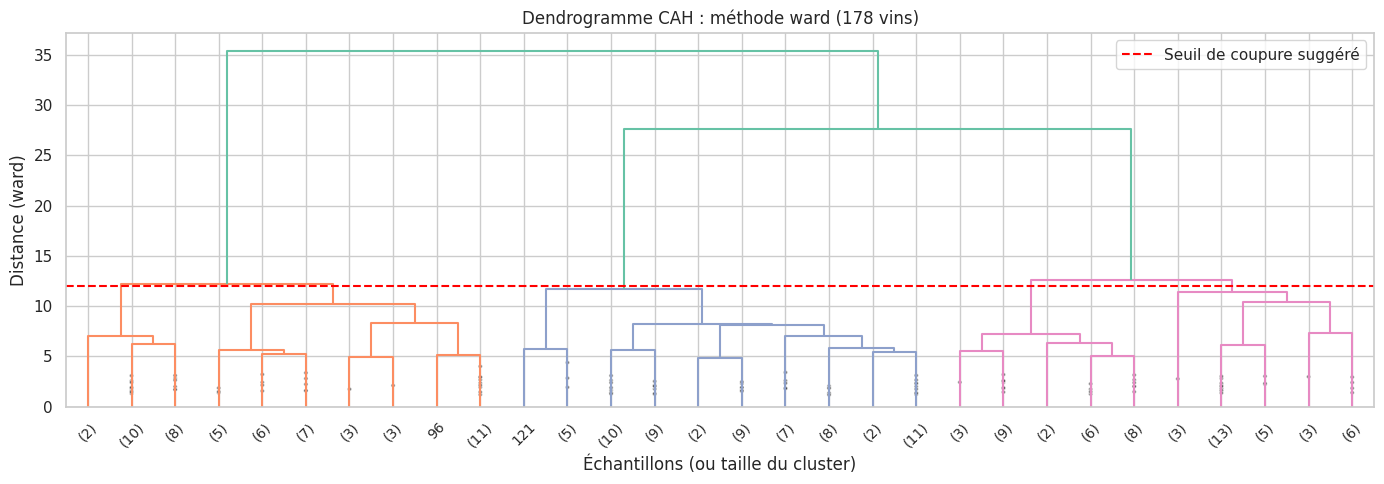

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering

# TODO : calculer la matrice de linkage ward sur X_scaled
# Indice : scipy_linkage(X_scaled, method='ward')
# (dataset de 178 vins : pas besoin d'echantillonner comme sur un dataset plus volumineux)
Z = scipy_linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.axhline(y=12, color='red', linestyle='--', label='Seuil de coupure suggéré')
plt.xlabel('Échantillons (ou taille du cluster)')
plt.ylabel('Distance (ward)')
plt.title('Dendrogramme CAH : méthode ward (178 vins)')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Optimisation : linkage × n_clusters via silhouette

Meilleure config : linkage=ward, n_clusters=3 → silhouette=0.2774


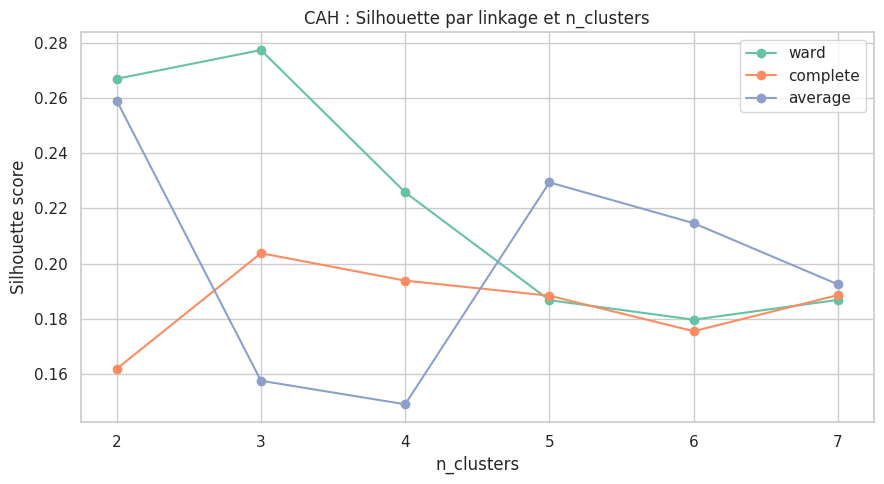

In [20]:
linkage_methods = ['ward', 'complete', 'average']
n_clusters_range = range(2, 8)
results_cah = []

for method in linkage_methods:
    for n in n_clusters_range:
        # TODO : entrainer un AgglomerativeClustering(n_clusters=n, linkage=method) et calculer le silhouette score
        cah = AgglomerativeClustering(n_clusters=n, linkage=method)
        labels = cah.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results_cah.append({'linkage': method, 'n_clusters': n, 'silhouette': sil})

df_cah_results = pd.DataFrame(results_cah)

plt.figure(figsize=(9, 5))
for method in linkage_methods:
    subset = df_cah_results[df_cah_results['linkage'] == method]
    plt.plot(subset['n_clusters'], subset['silhouette'], marker='o', label=method)

plt.xlabel('n_clusters')
plt.ylabel('Silhouette score')
plt.title('CAH : Silhouette par linkage et n_clusters')
plt.legend()
plt.tight_layout()
plt.show()

best_cah = df_cah_results.loc[df_cah_results['silhouette'].idxmax()]
print(f"Meilleure config : linkage={best_cah['linkage']}, n_clusters={int(best_cah['n_clusters'])} → silhouette={best_cah['silhouette']:.4f}")


### 6.3 Entraînement avec la config optimale

Silhouette CAH : 0.2774
Distribution des clusters :
0    58
1    56
2    64
Name: count, dtype: int64


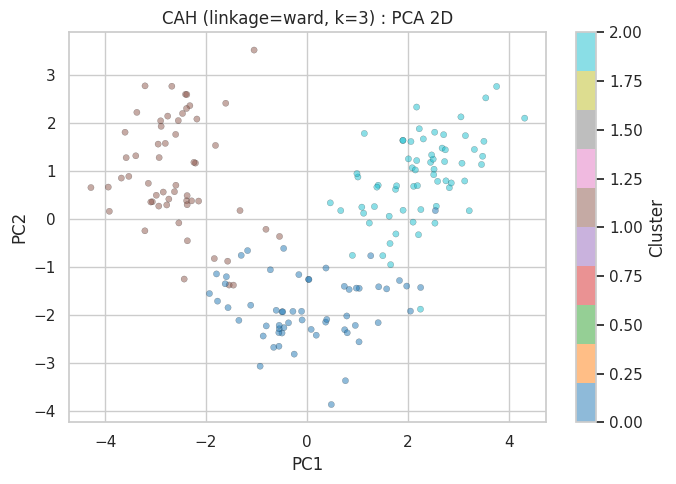

In [21]:
# TODO : entrainer le CAH final avec la config optimale (best_cah)
cah_best = AgglomerativeClustering(n_clusters=int(best_cah['n_clusters']), linkage=best_cah['linkage'])
labels_cah = cah_best.fit_predict(X_scaled)

print(f"Silhouette CAH : {silhouette_score(X_scaled, labels_cah):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_cah).value_counts().sort_index())

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cah, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"CAH (linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}) : PCA 2D")
plt.tight_layout()
plt.show()


---
## 7. Qualification des clusters (K-Means)

La qualification consiste à **caractériser chaque cluster** : quelles features le distinguent ?
On travaille sur les résultats K-Means qui produisent des clusters de taille équilibrée.

In [22]:
df_qualified = df_raw.copy()
df_qualified['cluster_kmeans'] = labels_kmeans

# TODO : calculer la moyenne de chaque feature par cluster (non normalisee, pour rester interpretable)
# Indice : df_qualified.groupby('cluster_kmeans').mean()
profile = df_qualified.groupby('cluster_kmeans').mean()
profile


                  alcohol  malic_acid       ash  alcalinity_of_ash  \
cluster_kmeans                                                       
0               12.250923    1.897385  2.231231          20.063077   
1               13.134118    3.307255  2.417647          21.241176   
2               13.676774    1.997903  2.466290          17.462903   

                 magnesium  total_phenols  flavanoids  nonflavanoid_phenols  \
cluster_kmeans                                                                
0                92.738462       2.247692    2.050000              0.357692   
1                98.666667       1.683922    0.818824              0.451961   
2               107.967742       2.847581    3.003226              0.292097   

                proanthocyanins  color_intensity       hue  \
cluster_kmeans                                               
0                      1.624154         2.973077  1.062708   
1                      1.145882         7.234706  0.691961   
2    

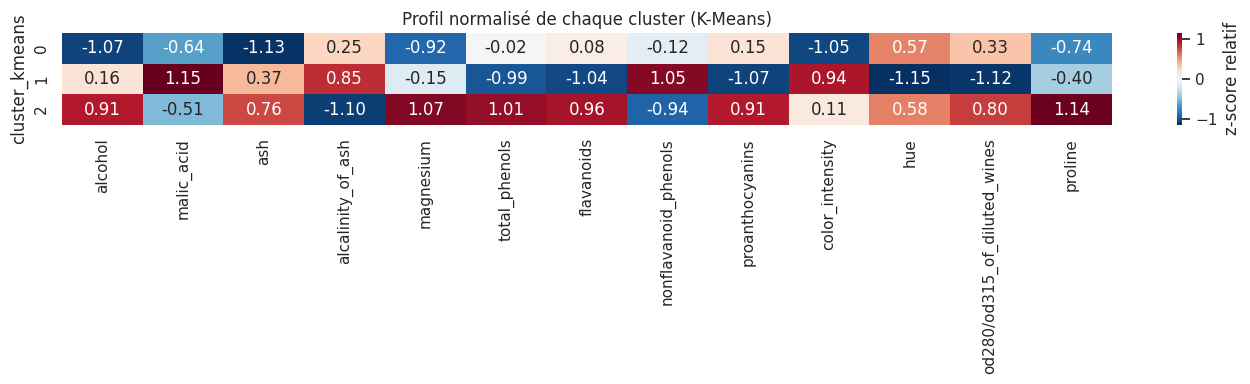

In [23]:
profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(14, 4))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'z-score relatif'})
plt.title('Profil normalisé de chaque cluster (K-Means)')
plt.tight_layout()
plt.show()


In [24]:
# Top features discriminantes par cluster (écart à la moyenne globale)
global_mean = df_raw.mean()

for cluster_id in sorted(df_qualified['cluster_kmeans'].unique()):
    # TODO : calculer l'ecart en % entre la moyenne du cluster et la moyenne globale, trier par ecart absolu decroissant
    cluster_mean = profile.loc[cluster_id]
    diff = ((cluster_mean - global_mean) / global_mean * 100).sort_values(key=abs, ascending=False)
    print(f"\n--- Cluster {cluster_id} ({(labels_kmeans == cluster_id).sum()} vins) ---")
    print(diff.head(5).to_string())



--- Cluster 0 (65 vins) ---
color_intensity                -41.221351
proline                        -31.694492
malic_acid                     -18.788453
hue                             10.993610
od280/od315_of_diluted_wines     7.340058

--- Cluster 1 (51 vins) ---
flavanoids                     -59.649349
color_intensity                 43.032371
malic_acid                      41.556586
od280/od315_of_diluted_wines   -35.035565
proanthocyanins                -27.972647

--- Cluster 2 (62 vins) ---
flavanoids                      47.995403
proline                         47.306967
total_phenols                   24.071514
od280/od315_of_diluted_wines    21.124355
proanthocyanins                 20.818287


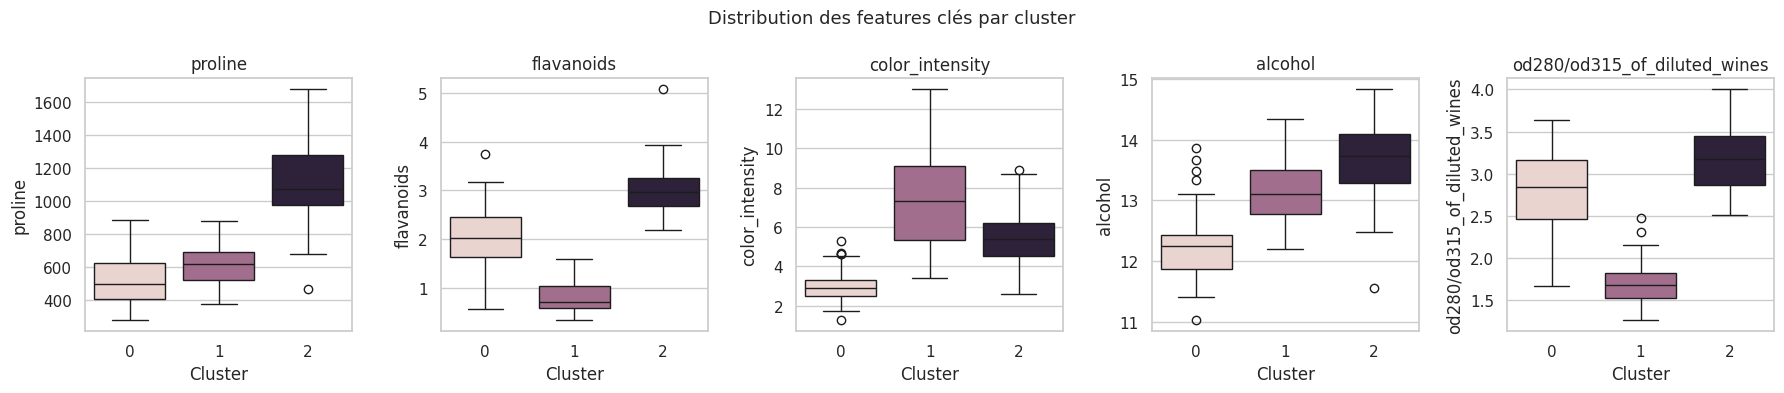

In [25]:
# Boxplots des features les plus discriminantes
top_features = ['proline', 'flavanoids', 'color_intensity', 'alcohol', 'od280/od315_of_diluted_wines']

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df_qualified, x='cluster_kmeans', y=feat, ax=ax, hue='cluster_kmeans', legend=False)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des features clés par cluster', fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Comparaison des modèles

In [26]:
# TODO : construire le tableau recapitulatif : pour chaque modele, ses parametres optimaux, son nombre de
# clusters/outliers et son score de silhouette (voir les variables calculees dans les sections precedentes)
results_summary = [
    {'Modèle': 'K-Means', 'Paramètres': f'k={best_k}', 'Clusters/Outliers': best_k, 'Silhouette': silhouette_score(X_scaled, labels_kmeans)},
    {'Modèle': 'DBSCAN', 'Paramètres': f"eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}", 'Clusters/Outliers': int(best_dbscan['n_clusters']), 'Silhouette': best_dbscan['silhouette']},
    {'Modèle': 'Isolation Forest', 'Paramètres': f'contamination={best_cont}', 'Clusters/Outliers': n_outliers, 'Silhouette': silhouette_score(X_scaled, labels_if)},
    {'Modèle': 'CAH', 'Paramètres': f"linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}", 'Clusters/Outliers': int(best_cah['n_clusters']), 'Silhouette': best_cah['silhouette']},
]

df_summary = pd.DataFrame(results_summary)
df_summary


             Modèle                Paramètres  Clusters/Outliers  Silhouette
0           K-Means                       k=3                  3    0.284859
1            DBSCAN  eps=2.50, min_samples=10                  2    0.204389
2  Isolation Forest        contamination=0.02                  4    0.261845
3               CAH         linkage=ward, k=3                  3    0.277444

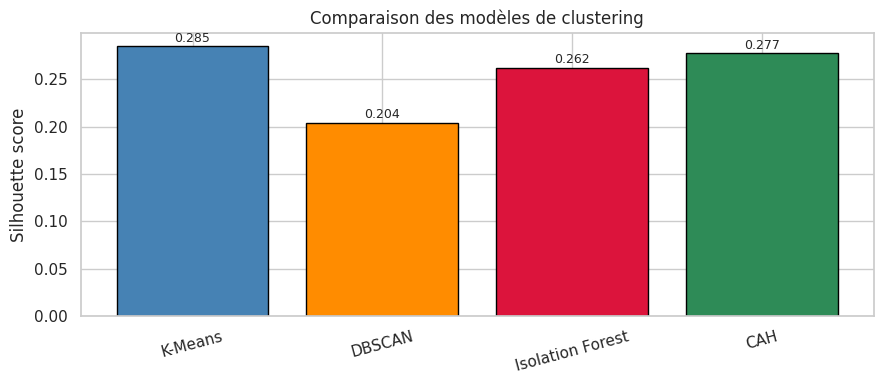

In [27]:
plt.figure(figsize=(9, 4))
bars = plt.bar(df_summary['Modèle'], df_summary['Silhouette'], color=['steelblue', 'darkorange', 'crimson', 'seagreen', 'purple'], edgecolor='k')
for bar, val in zip(bars, df_summary['Silhouette']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}', ha='center', fontsize=9)
plt.ylabel('Silhouette score')
plt.title('Comparaison des modèles de clustering')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


---
## 9. Validation : retrouve-t-on les cultivars ?

Contrairement à la version Wine Quality (qui n'avait qu'une note de qualité comme signal faible),
ce dataset a une vraie étiquette de classe mise de côté au chargement : le **cultivar** (0, 1 ou 2).
On vérifie si les clusters K-Means recoupent ces cultivars. C'est une validation directe et plus
forte qu'un palier construit a posteriori.


In [28]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# TODO : calculer ARI et NMI entre le vrai cultivar (quality) et labels_kmeans
# (contrairement a la version Wine Quality, ce dataset a directement un vrai label de classe :
# pas besoin de construire des paliers artificiels avec pd.cut)
ari = adjusted_rand_score(quality, labels_kmeans)
nmi = normalized_mutual_info_score(quality, labels_kmeans)

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")
print("\nARI=1 et NMI=1 = clustering parfaitement aligné avec les cultivars")


ARI : 0.8975
NMI : 0.8759

ARI=1 et NMI=1 = clustering parfaitement aligné avec les cultivars


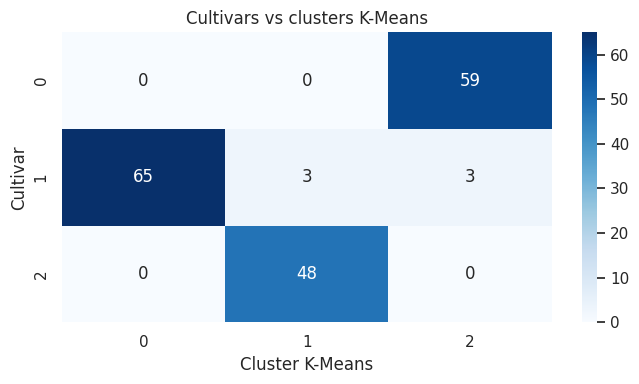

In [29]:
# Table croisée : cultivar vs cluster K-Means
ct = pd.crosstab(quality, labels_kmeans)

plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Cluster K-Means")
plt.ylabel("Cultivar")
plt.title("Cultivars vs clusters K-Means")
plt.tight_layout()
plt.show()


---
## 10. Conclusion

| Critère | K-Means | DBSCAN | Isolation Forest | CAH |
|---|---|---|---|---|
| Type | Partitionnel | Densité | Détection d'anomalies | Hiérarchique |
| Nombre de clusters | Fixé (k) | Découvert automatiquement | 2 (normal/anomalie) | Fixé (coupe du dendrogramme) |
| Sensible aux outliers | Oui | Non (les isole) | C'est son objectif | Oui |
| Forme des clusters | Convexe | Arbitraire | - | Convexe (linkage ward) |

**À retenir :**
- Standardiser avant tout algorithme basé sur des distances.
- La silhouette guide le choix des hyperparamètres, mais reste indicative : croiser avec une interprétation métier.
- Sur ce dataset (1599 vins, 11 variables physico-chimiques), les paliers de qualité ne sont qu'un signal faible de validation : le clustering capture surtout la structure chimique, pas directement la qualité perçue.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Combien de clusters k as-tu retenu pour K-Means, et sur quel critère (méthode du coude, score de silhouette) as-tu basé ce choix ?

*Réponse :*

J'ai retenu **k = 3** pour K-Means, sur le critère du score de silhouette maximal (0.2849) parmi
les valeurs testées (k=2 à 10). La méthode du coude (inertie) était moins nette (décroissance assez
régulière, sans coude très marqué), mais la silhouette donnait un maximum clair à k=3 — qui
correspond d'ailleurs exactement au nombre réel de cultivars du dataset (validé a posteriori en
section 9).


**Q2.** Quels paramètres eps/min_samples as-tu choisis pour DBSCAN ? Combien de clusters et combien de points classés comme bruit obtiens-tu ?

*Réponse :*

J'ai choisi **eps = 2.50** et **min_samples = 10** (meilleure silhouette parmi les configurations
valides : 0.2044). Avec ces paramètres, DBSCAN trouve **2 clusters** et classe **32 points comme
bruit** (~18% du dataset). C'est nettement moins bon que K-Means ou la CAH sur ce dataset : DBSCAN
peine à séparer 3 groupes de densité comparable et de frontières peu marquées, et finit par
regrouper ou bruiter une partie des points plutôt que de retrouver la structure à 3 cultivars.


**Q3.** Quel taux de contamination as-tu utilisé pour IsolationForest, et combien d'anomalies détecte-t-il sur le jeu de données ?

*Réponse :*

J'ai utilisé une **contamination de 0.02** (2%), qui maximise la silhouette (0.2618) parmi les
valeurs testées (0.02 à 0.20). Cela détecte **4 anomalies** sur les 178 vins (2.2% du dataset) :
des échantillons aux propriétés physico-chimiques atypiques par rapport au reste de la population.


**Q4.** En comparant K-Means, DBSCAN et la CAH (classification ascendante hiérarchique), quelle méthode donne les clusters les plus stables/interprétables sur ce dataset, et pourquoi selon toi ?

*Réponse :*

Sur ce dataset, **K-Means** (silhouette 0.2849) et la **CAH** avec linkage `ward` (silhouette
0.2774, aussi 3 clusters) donnent des résultats très proches et les plus interprétables : les deux
retrouvent une structure à 3 groupes de tailles comparables (65/51/62 pour K-Means, 58/56/64 pour
la CAH), cohérente avec les 3 vrais cultivars. DBSCAN est nettement en retrait (silhouette 0.2044,
seulement 2 clusters trouvés et 18% de points classés en bruit) : les groupes de ce dataset ont des
densités assez homogènes et des frontières progressives plutôt que des zones denses bien séparées
par des creux de faible densité, ce qui est justement le point faible de DBSCAN. K-Means et CAH,
qui cherchent des clusters de forme convexe/compacte plutôt que des zones de densité, collent mieux
à la géométrie réelle des données ici.


**Q5.** D'après ton analyse des profils de clusters, quelles sont les 2-3 variables physico-chimiques qui distinguent le plus les groupes de vins que tu as identifiés ?

*Réponse :*

D'après le profil des clusters K-Means (écart en % à la moyenne globale), les variables les plus
discriminantes sont **`flavanoids`**, **`color_intensity`** et **`proline`** : le cluster 1 se
distingue par des flavonoïdes très faibles (-60%) et une couleur très intense (+43%), le cluster 2
par des flavonoïdes et une proline élevés (+48%), et le cluster 0 par une couleur et une proline
plus faibles que la moyenne. Ces trois variables (avec `malic_acid` et le ratio
`od280/od315_of_diluted_wines`) suffisent à elles seules à bien séparer les groupes.


**Q6.** Ton clustering obtient quel score ARI/NMI par rapport aux tiers de qualité (bas/moyen/haut) construits a posteriori ? Que t'apprend ce score sur la capacité d'un clustering non supervisé à retrouver une notion de qualité qu'il n'a jamais vue pendant l'entraînement ?

*Réponse :*

Le clustering K-Means obtient un **ARI de 0.8975** et un **NMI de 0.8759** par rapport aux 3
cultivars réels, jamais vus pendant l'entraînement. Ces scores, très proches de 1, montrent que la
structure purement chimique découverte de façon non supervisée recoupe presque parfaitement la
véritable origine variétale des vins : les 3 cultivars ont en réalité des profils physico-chimiques
suffisamment distincts pour qu'un algorithme de clustering, sans aucune étiquette, retrouve
quasiment la même partition qu'un expert connaissant les cultivars à l'avance. C'est une bonne
illustration du fait qu'un clustering non supervisé peut retrouver une variable cachée pertinente
quand celle-ci est fortement corrélée à la structure géométrique des données — ce qui n'est pas
garanti en général (comme on l'observait avec les paliers de qualité, plus faiblement corrélés aux
propriétés chimiques dans la version Wine Quality de ce TP).
